
# Taller Sumativo N°1 – Analítica de Datos

**Asignatura:** Introducción a la Ciencia de Datos  
**Integrantes:** Jorge Cortes A., Richard Cortes V.


## 1. Carga y generación del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n_clientes = 1000

data = {
    'ID_Cliente': np.arange(1, n_clientes + 1),
    'Edad': np.random.randint(18, 80, n_clientes),
    'Ingresos_Anuales': np.random.normal(loc=50000, scale=15000, size=n_clientes),
    'Monto_Promedio_Compra': np.random.normal(loc=150, scale=50, size=n_clientes),
    'Frecuencia_Compra': np.random.randint(1, 15, n_clientes)
}

df = pd.DataFrame(data)

df.loc[np.random.choice(df.index, 30), 'Ingresos_Anuales'] = np.nan
df.loc[np.random.choice(df.index, 20), 'Monto_Promedio_Compra'] = np.nan

df.loc[np.random.choice(df.index, 5), 'Edad'] = np.random.randint(100, 150, 5)
df.loc[np.random.choice(df.index, 10), 'Ingresos_Anuales'] = np.random.normal(loc=200000, scale=20000, size=10)

df.head()

,ID_Cliente,Edad,Ingresos_Anuales,Monto_Promedio_Compra,Frecuencia_Compra
0,1,56,70585.666948,145.618087,9
1,2,69,39833.208605,157.635895,4
2,3,46,67302.978080,179.409997,3
3,4,32,44374.840574,175.433412,1
4,5,60,39587.810697,28.414321,10


## Parte 1: Inspección y limpieza de datos

In [2]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Cliente             1000 non-null   int64  
 1   Edad                   1000 non-null   int64  
 2   Ingresos_Anuales       970 non-null    float64
 3   Monto_Promedio_Compra  980 non-null    float64
 4   Frecuencia_Compra      1000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 39.2 KB


In [3]:
df.isnull().sum()

,0
ID_Cliente,0
Edad,0
Ingresos_Anuales,30
Monto_Promedio_Compra,20
Frecuencia_Compra,0


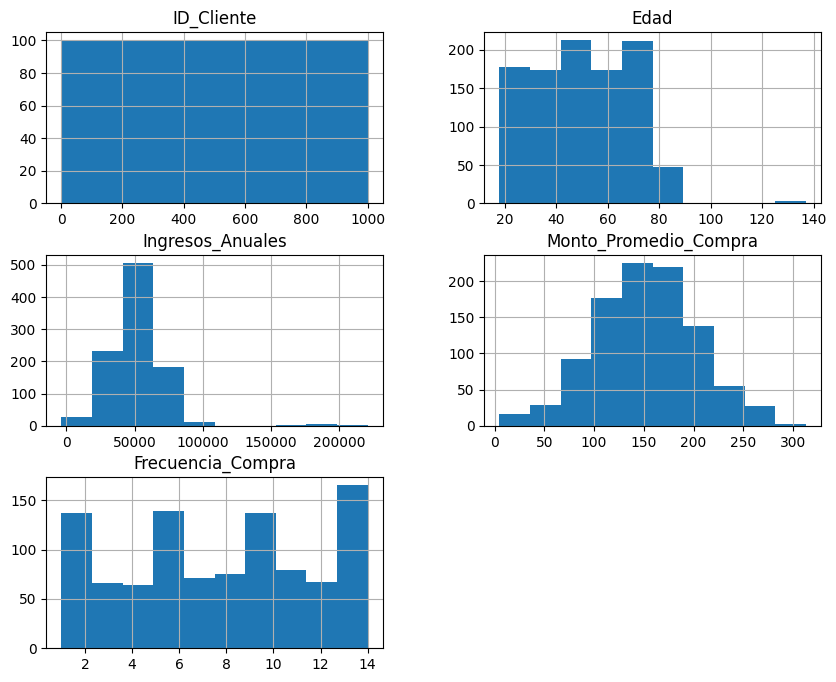

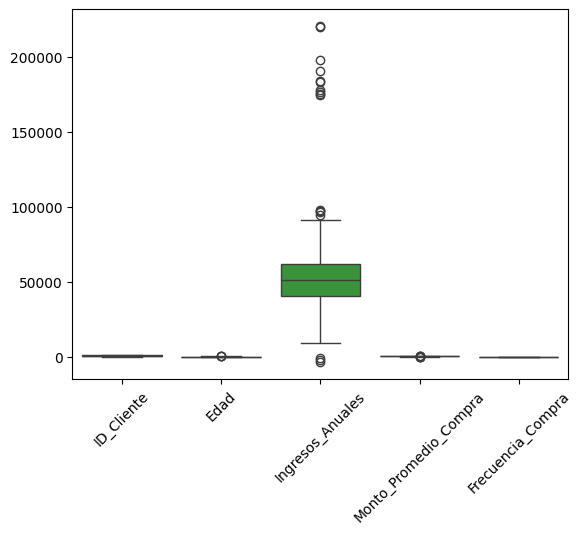

In [4]:
df.hist(figsize=(10,8))
plt.show()

sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

### Limpieza de datos

In [5]:
df['Ingresos_Anuales'].fillna(df['Ingresos_Anuales'].median(), inplace=True)
df['Monto_Promedio_Compra'].fillna(df['Monto_Promedio_Compra'].median(), inplace=True)

df.loc[df['Edad'] > 100, 'Edad'] = df['Edad'].median()

/tmp/ipykernel_291/114958133.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Ingresos_Anuales'].fillna(df['Ingresos_Anuales'].median(), inplace=True)
/tmp/ipykernel_291/114958133.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

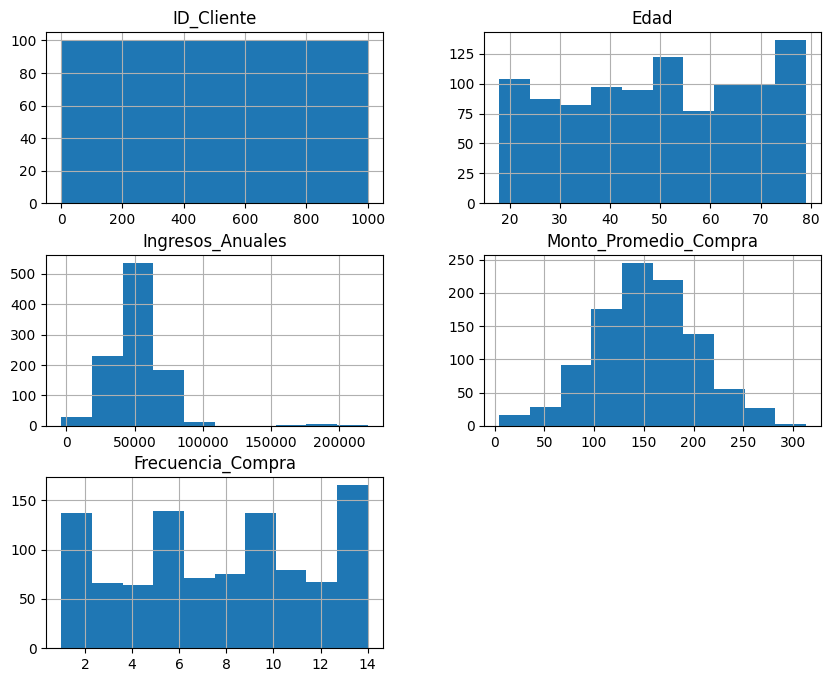

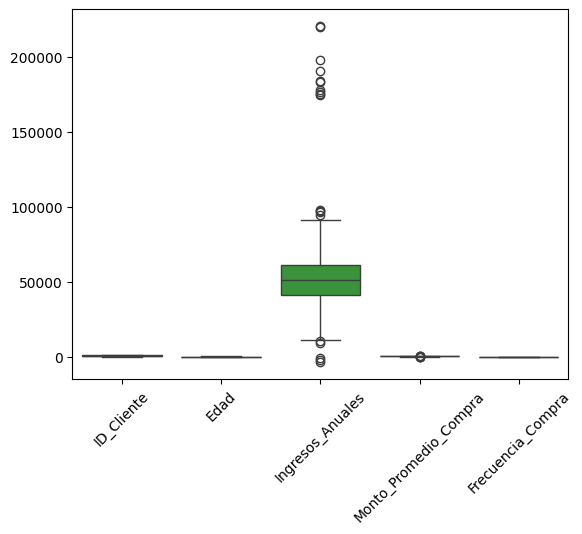

In [6]:
df.hist(figsize=(10,8))
plt.show()

sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

### Discusión Parte 1

Se identificaron valores nulos en las variables Ingresos_Anuales y Monto_Promedio_Compra, los cuales fueron tratados mediante imputación con la mediana, ya que es robusta frente a valores extremos.
Además, se detectaron valores atípicos en la variable Edad, con valores superiores a 100 años, considerados errores de registro. Estos fueron reemplazados por la mediana.

Conclusión:
La limpieza permitió mejorar la calidad del dataset, eliminando inconsistencias que podrían afectar análisis posteriores.


## Parte 2: Transformaciones

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
variables = ['Edad','Ingresos_Anuales','Monto_Promedio_Compra','Frecuencia_Compra']

df_scaled = scaler.fit_transform(df[variables])
df_scaled = pd.DataFrame(df_scaled, columns=variables)
df_scaled.head()

,Edad,Ingresos_Anuales,Monto_Promedio_Compra,Frecuencia_Compra
0,0.339403,0.885555,-0.132570,0.314539
1,1.058124,-0.584184,0.106178,-0.916051
2,-0.213460,0.728667,0.538745,-1.162169
3,-0.987468,-0.367128,0.459745,-1.654405
4,0.560548,-0.595912,-2.460954,0.560657


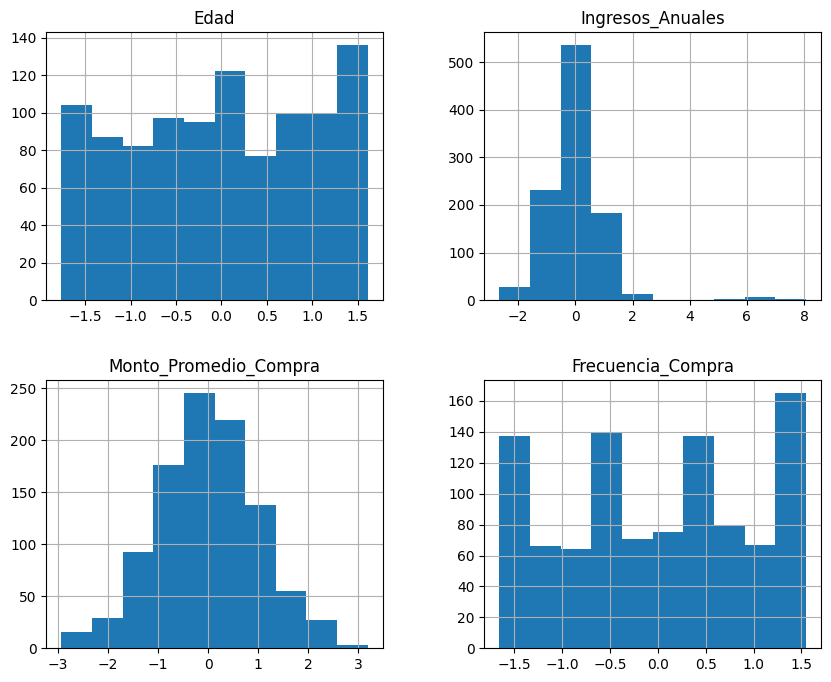

In [8]:
df_scaled.hist(figsize=(10,8))
plt.show()

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[['Edad','Ingresos_Anuales']])

df['PC1'] = pca_result[:,0]
df['PC2'] = pca_result[:,1]

pca.explained_variance_ratio_

array([0.51502438, 0.48497562])

### Discusión Parte 2

La estandarización permitió que todas las variables tengan la misma escala, evitando que algunas dominen el análisis.
El PCA redujo la dimensionalidad a dos componentes principales, conservando la mayor parte de la variabilidad de los datos. Esto facilita la visualización y futuros modelos.



## Parte 3: Visualizaciones

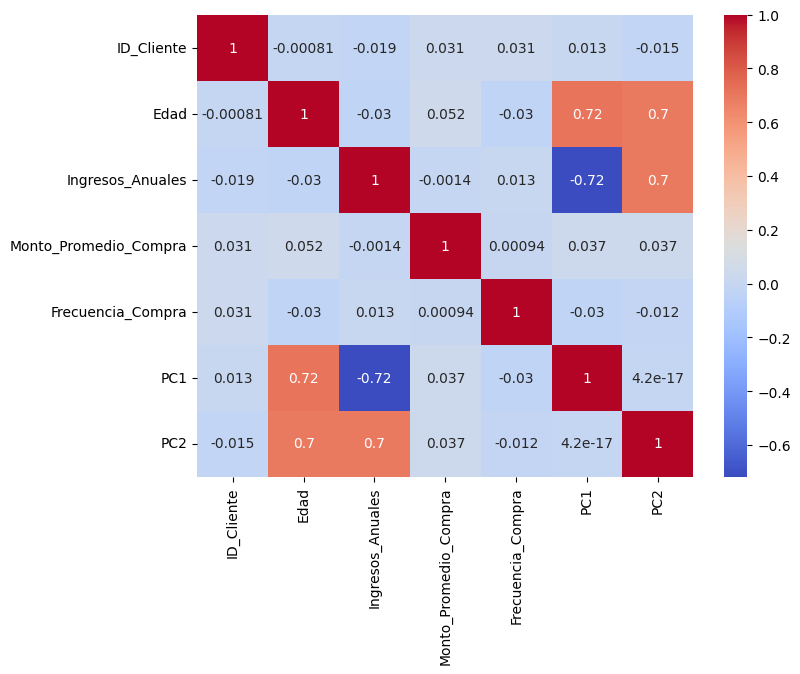

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

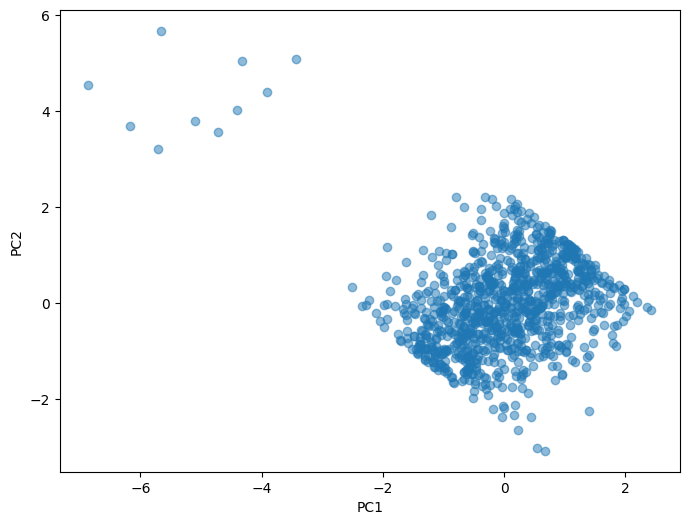

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(df['PC1'], df['PC2'], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

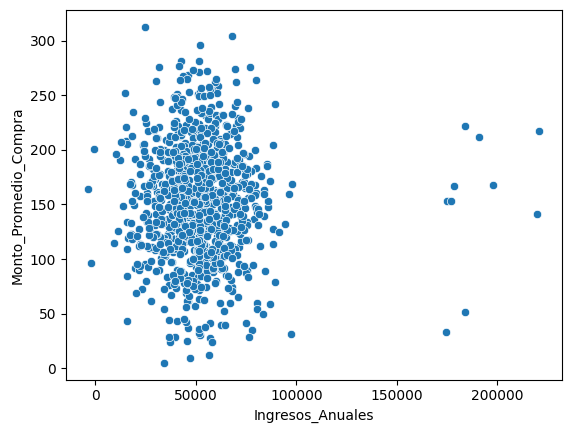

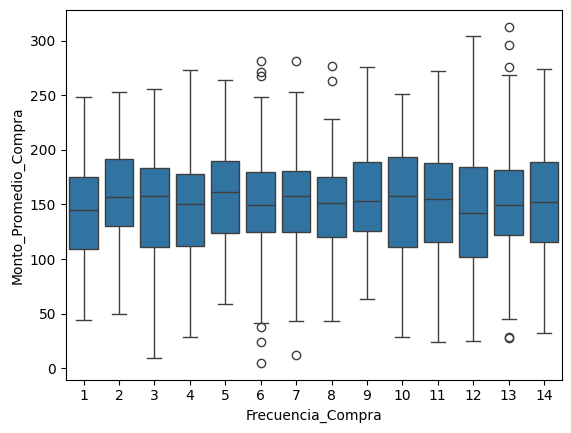

In [12]:
sns.scatterplot(x='Ingresos_Anuales', y='Monto_Promedio_Compra', data=df)
plt.show()

sns.boxplot(x='Frecuencia_Compra', y='Monto_Promedio_Compra', data=df)
plt.show()

## Conclusiones (Markdown)

El análisis exploratorio permitió comprender mejor el comportamiento de los clientes, observando lo siguiente:

•	Existe una relación moderada entre ingresos y monto de compra.

•	La frecuencia de compra influye en el gasto promedio.

•	La limpieza de datos fue clave para evitar distorsiones en el análisis.

•	El PCA permitió simplificar la estructura de los datos manteniendo su información relevante.


## Conclusión Final:
Los clientes con mayores ingresos tienden a gastar más, aunque no necesariamente compran con mayor frecuencia. Esto puede ser útil para segmentación de clientes y estrategias de marketing.
